In [ ]:
# Handling Categorical Missing Data
# Ways :
#     1. Replace with Most Frequent value
#     2. Replace with Missing

# 1. Most Frequent ->
#     - MCAR(Missing Completely At Random) - <5%
#     - Mode value should be way more than other values, 
#     - it changes the distribution of the data.

# 2. Replace with Missing ->
#     - MCAR - >10%
#     - create another category as named 'Missing'

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train (1).csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [3]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


In [4]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [5]:
# FireplaceQu    47.260274  -> this is 47%+ missing values (we shd not use most frequent imputer here,it ruined)
# GarageQual      5.547945  -> here we can apply

<Axes: xlabel='GarageQual'>

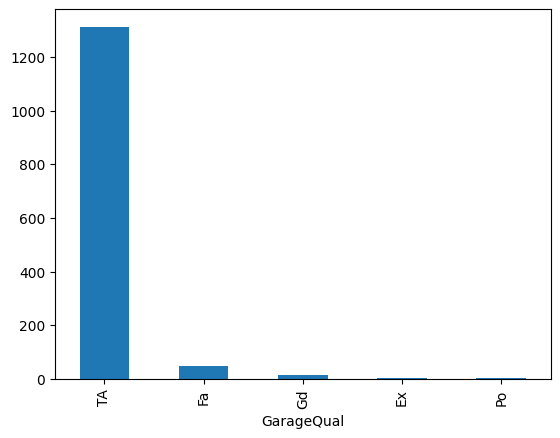

In [6]:
df['GarageQual'].value_counts().plot(kind='bar')

In [7]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

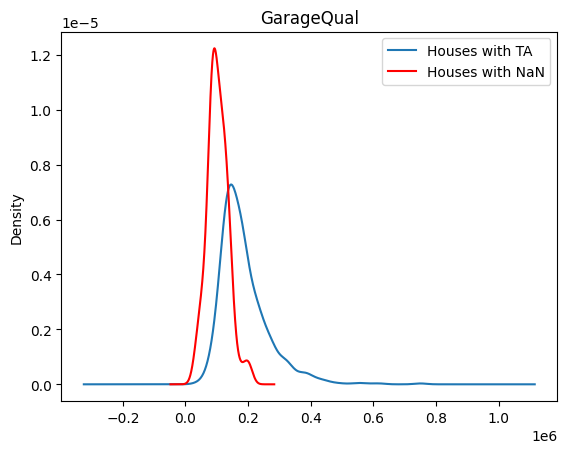

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines,labels = ax.get_legend_handles_labels()
labels = ['Houses with TA','Houses with NaN']
ax.legend(lines,labels, loc='best')

plt.title('GarageQual')

In [10]:
temp = df[df['GarageQual'] == 'TA']['SalePrice']

In [11]:
df['GarageQual'].fillna("TA",inplace=True)

C:\Users\hdewa\AppData\Local\Temp\ipykernel_14664\3259260982.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna("TA",inplace=True)


<Axes: xlabel='GarageQual'>

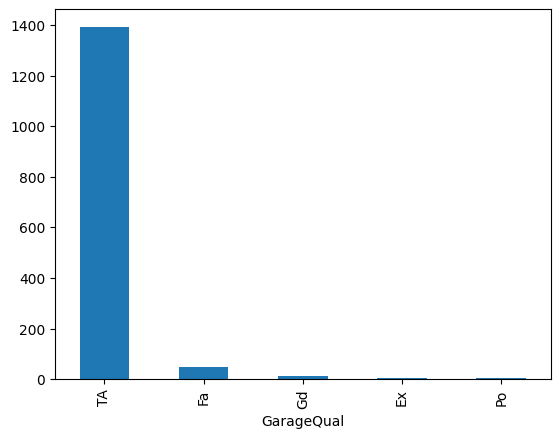

In [12]:
df['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

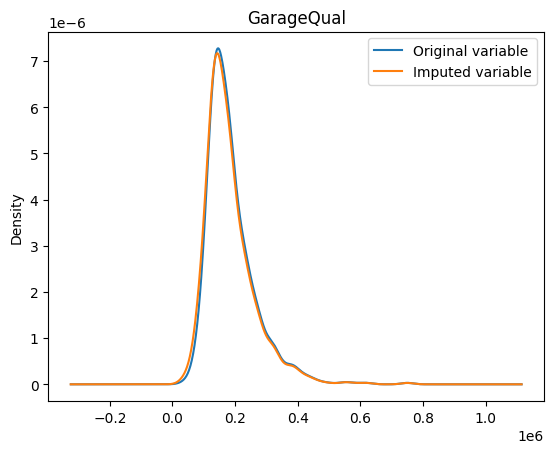

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation

df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

lines,labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines,labels, loc='best')

plt.title('GarageQual')

In [14]:
# we can see that both have similar distribution

<Axes: xlabel='FireplaceQu'>

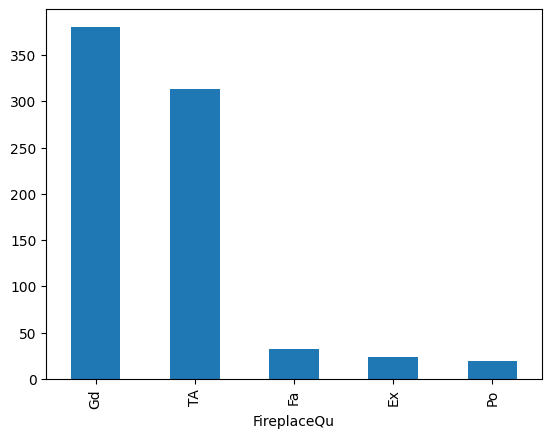

In [15]:
# But if we do with, FireplaceQu col -> which as much >5% missing values. So,

df['FireplaceQu'].value_counts().plot(kind='bar')


In [16]:
# 1st problem -> mode of this is not much higher than others(means- Gd is the mode but , TA is also close to it.)
# 2nd problem -> missing values are not in <5%

In [17]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

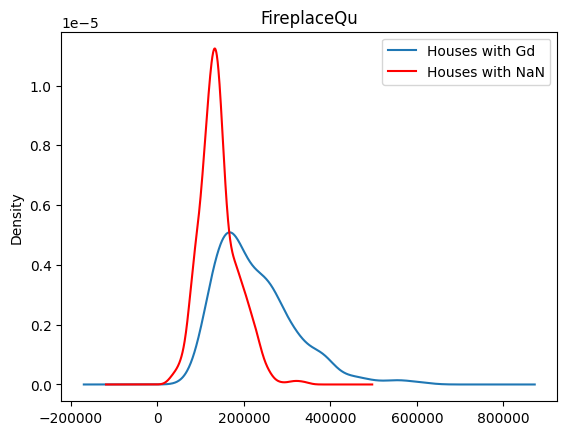

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NaN']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')

In [19]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [20]:
df['FireplaceQu'].fillna('Gd', inplace=True)

C:\Users\hdewa\AppData\Local\Temp\ipykernel_14664\3912738894.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd', inplace=True)


<Axes: xlabel='FireplaceQu'>

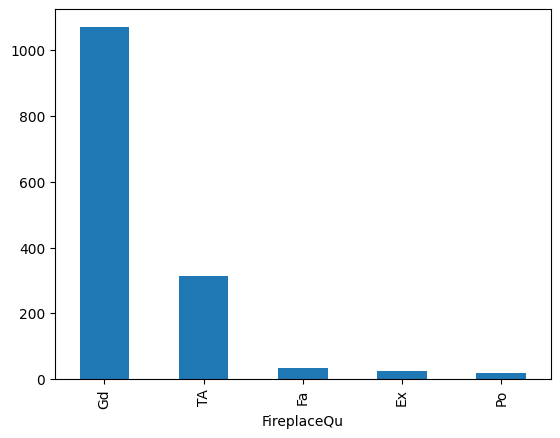

In [21]:
df['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FireplaceQu')

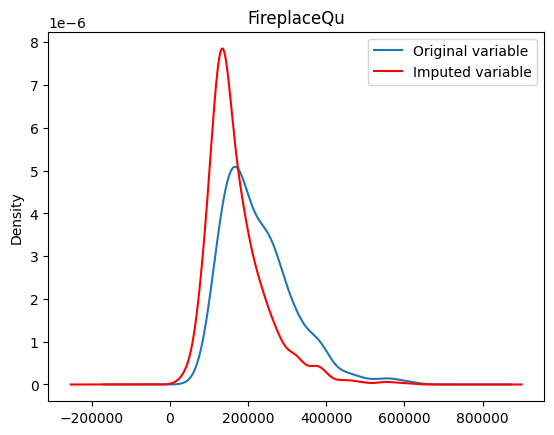

In [22]:

fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')

In [24]:
# so it is not, overlapping or closed, after imputation

In [25]:
# From sklearn

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [27]:
from sklearn.impute import SimpleImputer

In [28]:
impute = SimpleImputer(strategy='most_frequent')

In [29]:
X_train = impute.fit_transform(X_train)
X_test = impute.transform(X_test)

In [31]:
impute.statistics_

array(['Gd', 'TA'], dtype=object)